# Capire `vqe_trimer_chain_W.py` — guida interattiva

Questo notebook è il **mirror diretto**, per il trimero a catena aperta (N=3), di
`vqe_dimer_spiegato.ipynb` e di `vqe_trimer_ring_W_spiegato.ipynb`: stessa struttura,
stessi passi, stesso ansatz PMA "originale" (gate $W_{ij}(\theta)$, **non** RBS) con
**branching esplicito** sullo stato iniziale in base al campo.

Risponde in modo operativo a:
1. **Perché il VQE dà un limite superiore** all'energia (principio variazionale).
2. **Come l'estimator calcola** $\langle H\rangle_{\boldsymbol\theta}$.
3. **Come sono fatti i due ansätze** — hardware-efficient (HA) e physically motivated (PMA)
   — e perché il PMA usa meno parametri.
4. **Perché il branching è necessario** — un ramo forzato su tutto l'asse $b$ diverge
   fuori dalla propria regione.

> **Prerequisiti:** Qiskit 2.x, `numpy`, `scipy`, `matplotlib`; `ipywidgets` opzionale.
> `trimer_chain_exact.py` e `vqe_trimer_chain_W.py` nella stessa cartella.

**Scope.** Solo $D=0$, nessun termine DM — vedi nota di scope in
`vqe_trimer_chain_W.py`. I file relativi al VQE con DM per la catena verranno prodotti
separatamente.

Il modello è
$$H_0 = J\,\boldsymbol\sigma_1\cdot\boldsymbol\sigma_2 + J\,\boldsymbol\sigma_2\cdot\boldsymbol\sigma_3 + b\sum_{i=1}^3 Z_i.$$

## 0. Setup

In [1]:
import numpy as np
from scipy.optimize import minimize

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import n_local
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import Statevector, Operator

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", message=".*default.json.*")
warnings.filterwarnings("ignore", message="Style JSON file")

from trimer_chain_exact import (
    trimer_hamiltonian, exact_sweep, critical_field,
    magnetization_operator, kambe_states, ground_state_projector,
)
from vqe_trimer_chain_W import (
    make_ha_ansatz, make_pma_ansatz, make_pma_ansatz_forced, w_block,
    _select_target_block, _prepare_initial_state,
    run_vqe, run_vqe_forced, vqe_sweep, _plot_row,
    BOND12, BOND23,
)

try:
    from ipywidgets import interact, interact_manual, FloatSlider, IntSlider, Dropdown
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

print("Setup OK. Slider interattivi:", "si" if HAS_WIDGETS else "no (fallback statico)")


def show_circuit(qc, decompose=True):
    c = qc.decompose() if decompose else qc
    try:
        display(c.draw("mpl", style="iqp"))
    except Exception:
        print(c.draw())


def _mostra_figura(fig):
    from IPython.display import display as _d
    _d(fig)
    plt.close(fig)

Setup OK. Slider interattivi: si


## 1. Il principio variazionale

Stesso teorema del dimero e dell'anello, qui su una matrice $8\times8$: per
**qualsiasi** stato normalizzato $\ket\psi$,
$$\langle\psi|H|\psi\rangle \;\geq\; E_0,$$
con $E_0$ l'energia del ground state. Verifico con stati casuali a 3 qubit.

In [2]:
J = 1.0
H = trimer_hamiltonian(J, b=1.0).to_matrix()
E0 = float(np.linalg.eigvalsh(H)[0])
print(f"E0 (esatto) = {E0:.4f}\n")

rng = np.random.default_rng(0)
for _ in range(6):
    psi = rng.normal(size=8) + 1j * rng.normal(size=8)
    psi /= np.linalg.norm(psi)
    E = float(np.real(psi.conj() @ H @ psi))
    print(f"  stato casuale: <H> = {E:8.4f}   >= E0 ? {E >= E0 - 1e-12}")

E0 (esatto) = -5.0000

  stato casuale: <H> =   1.0495   >= E0 ? True
  stato casuale: <H> =  -0.4479   >= E0 ? True
  stato casuale: <H> =   0.3364   >= E0 ? True
  stato casuale: <H> =  -0.3288   >= E0 ? True
  stato casuale: <H> =  -2.1852   >= E0 ? True
  stato casuale: <H> =  -0.5100   >= E0 ? True


## 2. L'estimator: come si calcola $\langle H\rangle$

Stesso pattern del dimero e dell'anello: PUB `(ansatz, hamiltonian, [params])`,
`StatevectorEstimator`, `.evs.item()`. Verifico che coincida col calcolo manuale via
`Statevector`.

In [3]:
ansatz = n_local(3, "ry", "cz", entanglement="full", reps=2)
H_op = trimer_hamiltonian(J, b=1.0)
estimator = StatevectorEstimator()

params = np.linspace(0.1, 1.2, ansatz.num_parameters)

pub = (ansatz, H_op, [params])
E_est = estimator.run([pub]).result()[0].data.evs.item()

sv = Statevector(ansatz.assign_parameters(params)).data
E_man = float(np.real(sv.conj() @ H_op.to_matrix() @ sv))

print(f"<H> estimator = {E_est:.8f}")
print(f"<H> manuale   = {E_man:.8f}")
print(f"coincidono?     {np.isclose(E_est, E_man)}")

<H> estimator = 2.00638823
<H> manuale   = 2.00638823
coincidono?     True


## 3. L'ansatz hardware-efficient (HA)

Come nel dimero e nell'anello, `n_local`: strati $R_y$ + $CZ$, generico, nessuna
struttura fisica. Numero di parametri: $3(\text{reps}+1)$. Per `reps=2`: 9 parametri.

Parametri HA (reps=2): 9


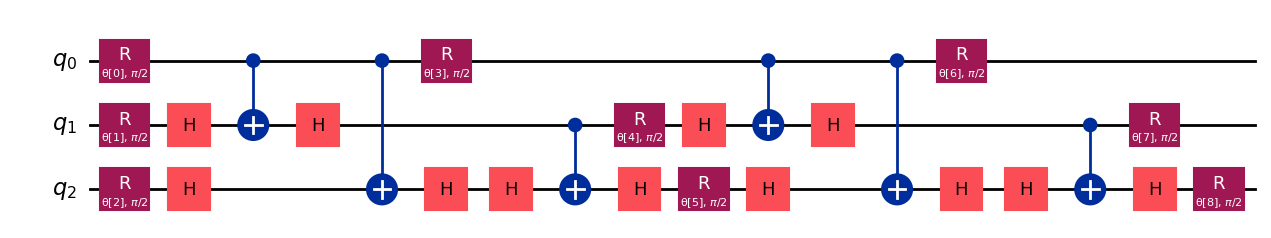

In [4]:
ha = make_ha_ansatz(reps=2)
print("Parametri HA (reps=2):", ha.num_parameters)
show_circuit(ha)

## 4. L'ansatz physically motivated (PMA)

Stesso principio del dimero e dell'anello, esteso ai **due legami fisici** della
catena (nessun legame $(3,1)$). Il blocco fondamentale agisce su ogni legame $(i,j)$,
identico gate del dimero:
$$W_{ij}(\theta) = \text{CNOT}_{ij}\,\big(R_y(\theta)_i\otimes I_j\big)\,\text{CNOT}_{ij}.$$

Lo stato iniziale rispetta la simmetria del ground state atteso (decomposizione di
Kambe sulla coppia *non* legata $1$–$3$):
- $b < b_c$: per $J>0$ il fondamentale a basso campo è **sempre** il blocco $B$ —
  *a differenza del dimero e dell'anello*, qui **non** è il singoletto banale: pesi
  $1/\sqrt6, 1/\sqrt6, -\sqrt{2/3}$ sui tre stati $|100\rangle,|001\rangle,|010\rangle$
  (vedi `derivazione_stati_kambe_trimero_catena.pdf`) — preparazione generica
  (`prepare_state`), non gate-ottimizzata.
- $b \geq b_c$: si parte da $\ket{A,-\frac32}=\ket{111}$ — **banale**, solo porte $X$.

Per $K$ layer (uno per legame fisico): **$2K$ parametri** (contro i $3K$ dell'anello:
un legame in meno).

### Perché si sceglie il riferimento in base al campo?

Stessa ragione del dimero e dell'anello: il fondamentale della catena **cambia
multipletto bruscamente** a $b_c$ (level crossing $B\to A$) — due stati completamente
diversi, non c'è un singolo riferimento fisso che vada bene ovunque con un ansatz
$M$-conservante.

Parametri PMA (K=1): 2

PMA sotto soglia (b<b_c), stato iniziale = blocco B (non banale):


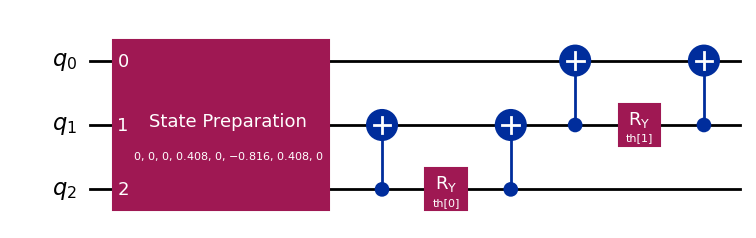


PMA sopra soglia (b>=b_c), stato iniziale = |111>:


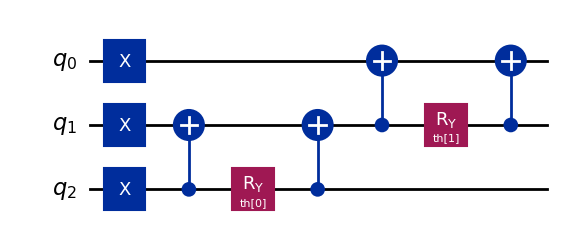

In [5]:
print("Parametri PMA (K=1):", make_pma_ansatz(J, 1.0).num_parameters)

print("\nPMA sotto soglia (b<b_c), stato iniziale = blocco B (non banale):")
show_circuit(make_pma_ansatz(J, 1.0), decompose=False)

print("\nPMA sopra soglia (b>=b_c), stato iniziale = |111>:")
show_circuit(make_pma_ansatz(J, 4.0), decompose=False)

### Verifica: `prepare_state` produce davvero lo stato $B$ atteso?

A differenza del dimero e dell'anello (dove il ramo a basso campo ha una derivazione a
mano semplice, $X,H,\mathrm{CX},X$), qui il blocco $B$ non è banale: non c'è una
sequenza corta di gate elementari da verificare a mano. Verifico invece numericamente
che `prepare_state` produca esattamente lo stato di Kambe $(B,-\frac12)$ atteso.

In [6]:
qc0 = QuantumCircuit(3)
vec = kambe_states()[("B", -0.5)]
qc0.prepare_state(vec.tolist(), [0, 1, 2])
sv0 = Statevector(qc0).data

print("Stato dopo la preparazione:")
print(np.round(sv0.real, 3))

print("\nStato di Kambe |B,-1/2> atteso:", np.round(vec.real, 3))
overlap = np.vdot(sv0, vec)
print(f"|overlap| = {abs(overlap):.6f}  (1 => preparazione corretta)")

Stato dopo la preparazione:
[-0.     0.    -0.     0.408 -0.    -0.816  0.408 -0.   ]

Stato di Kambe |B,-1/2> atteso: [ 0.     0.     0.     0.408  0.    -0.816  0.408  0.   ]
|overlap| = 1.000000  (1 => preparazione corretta)


### Perché basta $K=1$ per ciascun legame: la struttura a blocchi di $W_{ij}(\theta)$

Identica proprietà del dimero e dell'anello, gate per gate: la matrice $4\times4$ di
$W_{ij}(\theta)$ è **diagonale a blocchi**, con la **stessa** rotazione sia su
$\{\ket{01},\ket{10}\}$ sia su $\{\ket{00},\ket{11}\}$ — è letteralmente lo stesso gate
del dimero, verificato qui isolandolo:

In [7]:
theta_test = 0.7
qc_W = QuantumCircuit(2); qc_W.cx(0, 1); qc_W.ry(theta_test, 0); qc_W.cx(0, 1)
U = Operator(qc_W).data
np.set_printoptions(precision=3, suppress=True)
print("Matrice di W(theta), base |00>,|01>,|10>,|11>:")
print(U.real)

c, s = np.cos(theta_test/2), np.sin(theta_test/2)
print(f"\ncos(theta/2)={c:.3f}  sin(theta/2)={s:.3f}  -> su ENTRAMBI i blocchi diagonali")

Matrice di W(theta), base |00>,|01>,|10>,|11>:
[[ 0.939  0.     0.    -0.343]
 [ 0.     0.939  0.343  0.   ]
 [ 0.    -0.343  0.939  0.   ]
 [ 0.343  0.     0.     0.939]]

cos(theta/2)=0.939  sin(theta/2)=0.343  -> su ENTRAMBI i blocchi diagonali


### Verifica: cosa succede se si forza un ramo su tutto l'asse $b$?

Stesso esperimento del dimero e dell'anello: forzo ciascun ramo (basso/alto campo) su
**tutto** l'asse $b$, non solo dove è quello giusto, e confronto con la forma chiusa
esatta.

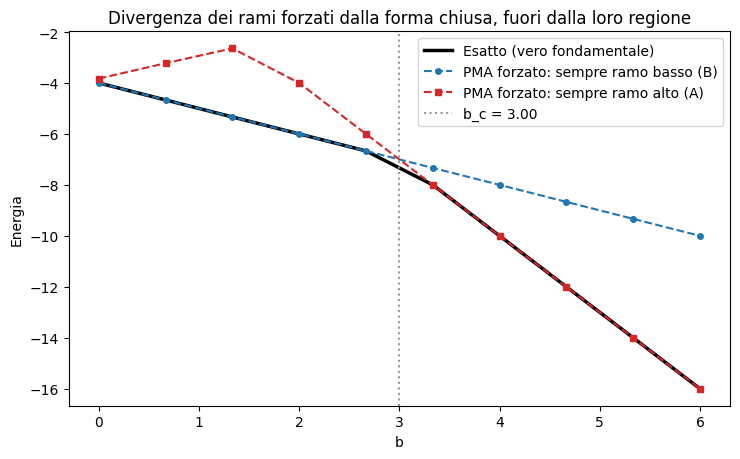

Errore massimo ramo basso per b>b_c: 6.0000
Errore massimo ramo alto per b<b_c:  2.6920
(entrambi crescono allontanandosi da b_c, come nel dimero e nell'anello)


In [8]:
b_vals = np.linspace(0.0, 6.0, 10)
E_basso = np.array([run_vqe_forced(J, b, "basso", n_restarts=3) for b in b_vals])
E_alto  = np.array([run_vqe_forced(J, b, "alto",  n_restarts=3) for b in b_vals])
E_esatto = exact_sweep(b_vals, J=J)["gs_energy"]

fig, ax = plt.subplots(figsize=(7.5, 4.7))
ax.plot(b_vals, E_esatto, "k-", lw=2.5, label="Esatto (vero fondamentale)")
ax.plot(b_vals, E_basso, "--o", color="tab:blue", ms=4, label="PMA forzato: sempre ramo basso (B)")
ax.plot(b_vals, E_alto, "--s", color="tab:red", ms=4, label="PMA forzato: sempre ramo alto (A)")
bc = critical_field(J)
ax.axvline(bc, color="0.6", ls=":", label=f"b_c = {bc:.2f}")
ax.set_xlabel("b"); ax.set_ylabel("Energia")
ax.set_title("Divergenza dei rami forzati dalla forma chiusa, fuori dalla loro regione")
ax.legend(); fig.tight_layout()
_mostra_figura(fig)

err_basso_oltre = np.max(np.abs(E_basso - E_esatto)[b_vals > bc])
err_alto_sotto  = np.max(np.abs(E_alto - E_esatto)[b_vals < bc])
print(f"Errore massimo ramo basso per b>b_c: {err_basso_oltre:.4f}")
print(f"Errore massimo ramo alto per b<b_c:  {err_alto_sotto:.4f}")
print("(entrambi crescono allontanandosi da b_c, come nel dimero e nell'anello)")

**Lettura.** Stessa conclusione del dimero e dell'anello: ciascun ramo forzato
coincide con la forma chiusa **solo dentro la propria regione**, diverge fuori — non un
piccolo errore di ottimizzazione, un limite strutturale del sottospazio raggiungibile
($W_{ij}$ non fa mai uscire lo stato dal settore in cui è stato messo dalla
preparazione iniziale). È esattamente perché il PMA vero **deve** switchare ramo in
base a $b$.

## 5. Il loop di ottimizzazione

Stesso schema del dimero e dell'anello: `StatevectorEstimator` (quantistico) +
`scipy.optimize.minimize` (classico), ottimizzazione a due stadi (COBYLA poi polish
L-BFGS-B, mandato del relatore), impacchettata in `run_vqe`
(`vqe_trimer_chain_W.py`).

In [9]:
out = run_vqe(J, 1.0, ansatz_type="HA", n_restarts=3)
print(f"HA, b=1.0, D=0:  E_vqe={out['e_vqe']:.6f}  E_exact={out['e_exact']:.6f}"
      f"  dE={out['delta_e']:+.2e}  F={out['fidelity']:.4f}  ({out['n_params']} par)")

HA, b=1.0, D=0:  E_vqe=-5.000000  E_exact=-5.000000  dE=+1.03e-13  F=1.0000  (9 par)


## 6. La fidelity

Come per l'anello: uso il **proiettore** sul multipletto fondamentale,
$\mathcal F=\langle\psi|P_0|\psi\rangle$, non il semplice overlap. Il fondamentale
della catena è degenere esattamente a $b_c$ (crossing $B\to A$).

In [10]:
for at in ["HA", "PMA"]:
    o = run_vqe(J, 1.0, ansatz_type=at, n_restarts=3, seed=1)
    print(f"{at:>3}  b=1.0  D=0:  F = {o['fidelity']:.6f}   ({o['n_params']} parametri)")

 HA  b=1.0  D=0:  F = 1.000000   (9 parametri)
PMA  b=1.0  D=0:  F = 1.000000   (2 parametri)


## 7. Il risultato: HA vs PMA su una griglia

*(Griglia ridotta, $n_b=15$, $R=2$, per contenere i tempi del notebook — la
validazione ufficiale, $R=6$ come da mandato, è già in `vqe_trimer_chain_W.py`.)*

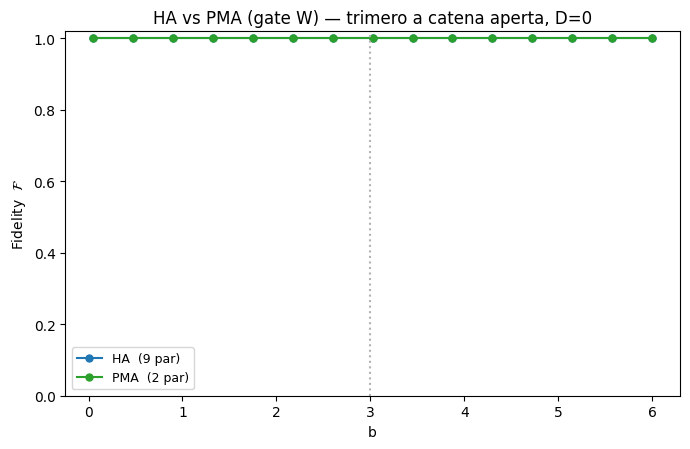

In [16]:
b_vals = np.linspace(0.05, 6.0, 15)
configs = [("HA", "tab:blue"), ("PMA", "tab:green")]

fig, ax = plt.subplots(figsize=(7, 4.6))
for at, c in configs:
    res = vqe_sweep(b_vals, J=J, ansatz_type=at, n_restarts=2, seed=1, verbose=False)
    fid = [r["fidelity"] for r in res]
    npar = res[0]["n_params"]
    ax.plot(b_vals, fid, "-o", color=c, ms=5, label=f"{at}  ({npar} par)")

bc = critical_field(J)
ax.axvline(bc, color="0.7", ls=":")
ax.set_ylim(0.0, 1.02); ax.set_xlabel("b"); ax.set_ylabel(r"Fidelity  $\mathcal{F}$")
ax.set_title("HA vs PMA (gate W) — trimero a catena aperta, D=0")
ax.legend(fontsize=9); fig.tight_layout()
_mostra_figura(fig)

## 8. Esplorazione interattiva

Slider per ansatz, $J$, $b$. (Con `ipywidgets`; altrimenti esempio statico.)

In [17]:
def explore(ansatz_type="PMA", J=1.0, b=3.0, K=1, reps=2, n_restarts=4):
    o = run_vqe(J, b, ansatz_type=ansatz_type, reps=reps, K=K, n_restarts=n_restarts)
    used = f"reps={reps}" if ansatz_type == "HA" else f"K={K}"
    print(f"ansatz={ansatz_type} ({used})  J={J}  b={b}  ({o['n_params']} parametri)")
    print(f"  E_vqe   = {o['e_vqe']:.5f}")
    print(f"  E_exact = {o['e_exact']:.5f}")
    print(f"  Delta E = {o['delta_e']:+.3e}")
    print(f"  Fidelity= {o['fidelity']:.4f}")
    print(f"  <Mz>    = {o['mz_vqe']:+.3f}")

if HAS_WIDGETS:
    ansatz_dd = Dropdown(options=["HA", "PMA"], value="PMA", description="ansatz_type")
    reps_slider = IntSlider(min=1, max=4, step=1, value=2, description="reps")
    K_slider = IntSlider(min=1, max=3, step=1, value=1, description="K")

    def _sync(change=None):
        is_ha = (ansatz_dd.value == "HA")
        reps_slider.layout.display = "" if is_ha else "none"
        K_slider.layout.display = "none" if is_ha else ""
    ansatz_dd.observe(_sync, names="value")
    _sync()

    interact_manual(explore,
                    ansatz_type=ansatz_dd,
                    J=FloatSlider(min=-2.5, max=2.5, step=0.1, value=1.0),
                    b=FloatSlider(min=0.0, max=6.0, step=0.1, value=3.0),
                    K=K_slider, reps=reps_slider,
                    n_restarts=IntSlider(min=1, max=6, step=1, value=4))
else:
    explore("PMA", 1.0, 3.0)

interactive(children=(Dropdown(description='ansatz_type', index=1, options=('HA', 'PMA'), value='PMA'), FloatS…

## 9. Riepilogo

1. **Principio variazionale:** $\langle H\rangle_{\boldsymbol\theta}\geq E_0$, quindi il VQE
   approssima il ground state **da sopra**.
2. **Estimator:** `StatevectorEstimator`, PUB `(ansatz, H, [params])`, `.evs.item()`.
3. **HA:** generico (`n_local`, Ry+CZ), $3(\text{reps}+1)$ parametri.
4. **PMA (questo notebook):** gate $W_{ij}$ sui due legami fisici, stato iniziale a
   $(S_{13},M)$ definiti scelto in base al campo (**branching esplicito**), $2K$
   parametri. Mirror diretto del PMA "originale" del dimero e dell'anello — non la
   versione RBS senza branching già validata in `vqe_trimer_chain.py`, né la versione
   senza branching in `vqe_trimer_chain_nobranch.py`.
5. **Differenza rispetto al dimero e all'anello:** qui il ramo a basso campo (blocco
   $B$) **non è banale** — niente derivazione a mano con $X,H,\mathrm{CX},X$, solo
   verifica numerica di `prepare_state` (§4). Il ramo ad alto campo ($|111\rangle$)
   resta banale come negli altri due sistemi.
6. **DM:** deliberatamente fuori scope in questo notebook — verrà affrontato in file
   dedicati, separati, da ripensare da zero per la catena (non condizionati dalle
   scelte già fatte per l'anello).
7. **Prossimo passo:** notebook di confronto sistematico (sul modello di
   `confronto_ansatz_entangler_trimero_catena.ipynb`), per includere anche gli ansatz
   $W$ appena costruiti insieme a quelli RBS già presenti.